# 3.0. técnicas de agrupamiento

## 3.1. Agrupación Mean-Shift

### Mean shift

Mean shift es un algoritmo de aprendizaje no upervisado que se utiliza principalmente para agrupación, a diferencia de los algoritmos de aprendizaje supervisado el agrupamiento intenta agrupar datos sin haber sido entrenados primero.

En este algoritmo, cada punto se desplaza a la media regional, paso a paso, y la ubicación del destino final de cada punto representa el grupo al que pertenece.

Una desventaja de este algortmo, es su alto costo computacional.

En genral, la agrupación en cluster se utiliza en una amplia variedad de aplicaciones, como motores de búsqueda, clasificaciones académicas y en medicina.

El algoritmo de desplazamiento medio tiene aplicaciones en el campo del procesamiento de imágenes y la visión artificial.

### Desafío

Encontrar los clústeres y graficarlos en 3D, para lograr esto, debemos seguir los siguientes tres pasos:

  1. Usar los datos generados por medio de `make_blobs` para entrenar el modelo de MEanShift.
  2. Obtener las coordenadas de lops clústres.
  3. Trazar los puntos de datos y los centroides en un gráfico con la clase pyplot de matplotlib.

### Code | Agrupación Mean-Shift

In [125]:
### Code | Agrupación Mean-Shift

from sklearn.cluster import MeanShift,  estimate_bandwidth
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

In [126]:
clusters = [[6,6,6], [2,2,2]]
X, y = make_blobs(centers=clusters, cluster_std=0.7, random_state=0)

In [127]:
bandwidth = estimate_bandwidth(X, n_samples=500)  # bandwidth: "ancho de banda" o "ancho de ventana" para el kernel
mean_shift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
mean_shift.fit(X)
cluster_centers = mean_shift.cluster_centers_

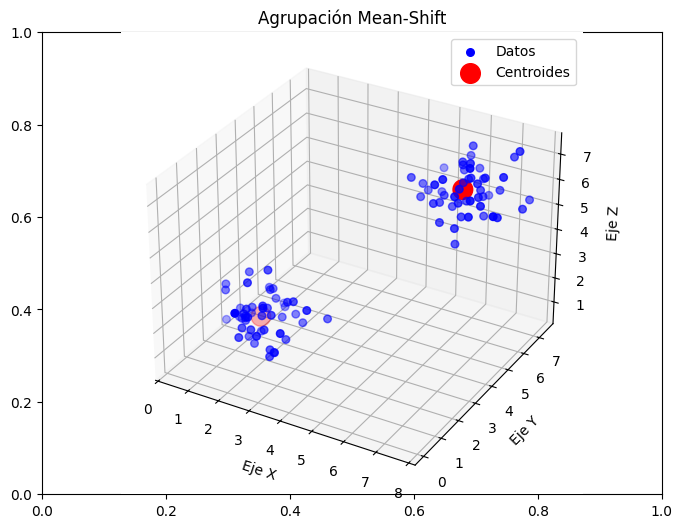

In [128]:
fig, ax = plt.subplots(figsize=(8, 6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], 
           c='blue', 
           marker='o', 
           s=30, 
           label='Datos')

ax.scatter(cluster_centers[:, 0], 
           cluster_centers[:, 1], 
           cluster_centers[:, 2], 
           c='red', 
           marker='o', 
           s=200, 
           label='Centroides')

ax.set_title('Agrupación Mean-Shift')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
plt.legend()

## 3.2. Agrupamiento de K-means

### Agrupación de clústeres K-Means

K-means es una técnica de aprendizaje automático no supervisado que se utiliza para identificar grupos de objetos de datos en un conjunto de datos.

#### K-means

  - Itera dividiendo un grupo de `n` conjuntos en `k`conjuntos:
    1. En función de la similitud. 
    2. En función de su disancia media desde el centroide del subgrupo formado.

### Desafío

Encontrar los grupos que tenemos presentes en nuestros datos, haciendo uso del método de agrupación de k-means.

  1. Cargar los archivos `clusters.csv` en el dataframe.
  2. Divide los datos en custro grupos utilizando k-means de scikit-learn.
  3. Haz una predicción basada en este modelo (k-means).
  4. Imprime las coordenadas del centroide de cada grupo.
  5. Grafica los resultados y los centroides de las agrupaciones determinados por el estimador k-means.


### Code | Agrupamiento de K-means

In [129]:
### Code | Agrupamiento de K-means

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [130]:
df = pd.read_csv('../data/clusters.csv', delimiter=";")
df.head()

,Latitud,Longitud
0,8.9784,-83.0378
1,8.9786,-83.0833
2,9.0236,-83.0377
3,8.9786,-83.0833
4,9.0246,-83.3104


In [131]:
k_means = KMeans(n_clusters=4)
k_means.fit(df)
y_kmeans = k_means.predict(df)
cluster_centers = k_means.cluster_centers_

Text(0, 0.5, 'Longitud')

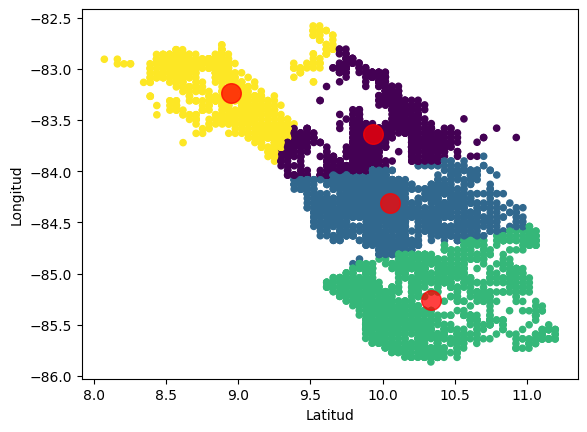

In [132]:
plt.scatter(df['Latitud'], 
            df['Longitud'], c=y_kmeans, 
            s=20, 
            cmap='viridis')

plt.scatter(cluster_centers[:, 0], 
            cluster_centers[:, 1], 
            c='red', 
            s=200, 
            alpha=0.75)

plt.xlabel('Latitud')
plt.ylabel('Longitud')

## 3.3. Agrupación jerárquica

### Agrupamiento jerarquico

  - Es un modelo de aprendizaje no supervisado para agrupar puntos de datos.
  - el algoritmo crea grupos midiendo las diferencias entre los datos.

#### Aprendizaje no supervisado

  - No es necesario entrenar un modelo y no se necesita una variable "objetivo".
  - Se puede utilizar en cualquier dato  para visualizar e interpretar la relación entre puntos de datos individuales.

### Desafío

Analizar los clientes de  la boutique llamada "El buen gusto".

  1. Crear un dendograma para decir el número de clústeres.
  2. Crear un modelo de agrupamiento gerárquico agromérativo de skit-learn, con  la cantidad de clústeres que encontró en el punto 1.
  3. Encontrar las etiquetas de los puntos.
  4. Graficar los grupos. 

#### Preguntas del desafío

  - ¿Hay alguna forma de determinar qué clientes son similares?
  - ¿Cuántos de ellos pertenecen al mismo grupo?
  - ¿Cuántos grupos diferentes hay?



### Code | Agrupación jerárquica

In [133]:
### Code | Agrupación jerárquica

import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [134]:
df = pd.read_csv('../data/clientes.csv', delimiter=";")
df.head()

,Salario,Gasto
0,1500,0.08
1,1500,0.25
2,1600,0.11
3,1600,0.06
4,1700,0.21


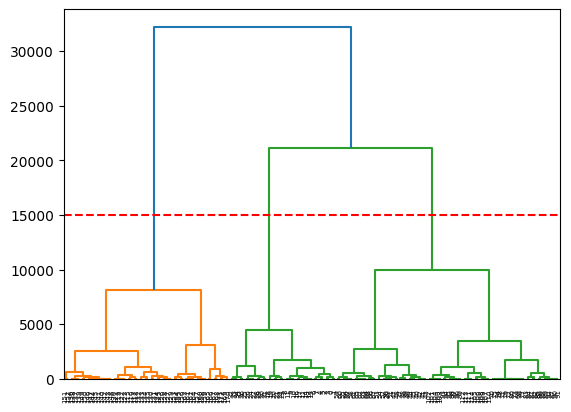

In [135]:
dendrogram = dendrogram(linkage(df, method='ward', metric='euclidean'))
plt.axhline(y=15000, color='r', linestyle='--')

In [136]:
agglomerative = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

agglomerative.fit(df)
labels = agglomerative.labels_
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Text(0, 0.5, 'Porcentaje de Gastos Mensuales')

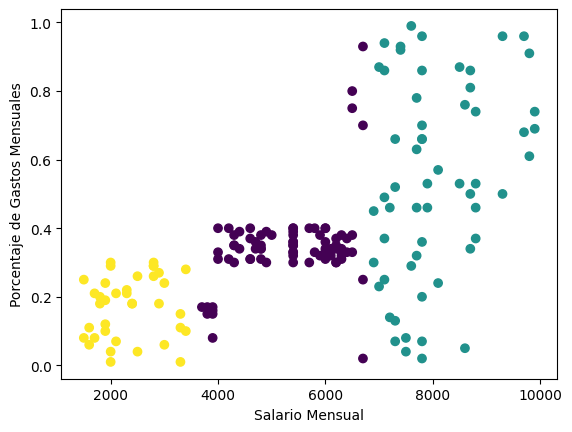

In [137]:
plt.scatter(df['Salario'], df['Gasto'], c=labels, cmap='viridis')
plt.xlabel('Salario Mensual')
plt.ylabel('Porcentaje de Gastos Mensuales')

## 3.4. Agrupamiento DBSCAN

### Agrupamiento espacial de aplicaciones con ruido basado en la densidad (DBSCAN)

  - Algoritmo de agrupamiento no supervisado basado en la densidad.
  - En DBSCAN los clústeres se forman a partir de regiones densas.
  - Las regiones se separan por regiones de densidad baja o nula.

DBSCAN calcula los gráficosde vecinos más cercanos y crea grupos de forma arbitraria en conjuntos de datos que pueden contener ruido o valores atípicos.

### Desafío

Mostrar los grupos que se forman a partir de los datos que se nos han dado.

  1. Craer el modelo y ajustar el modelo usando la clase de DBSCAN de skitlearn.
  2. Imprimir las etiquetas.
  3. Graficar los grupos.



### Code | Agrupamiento DBSCAN

In [138]:
### Code | Agrupamiento DBSCAN

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [139]:
df = pd.read_csv('../data/datos_dbscan.csv', delimiter=";")
df.head()

,Variable1,Variable2
0,-4.030499,-6.955657
1,-6.687653,7.467359
2,-3.334960,5.775981
3,-5.812554,-7.506389
4,-6.648924,7.142999


In [140]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(df)
labels = dbscan.labels_
labels

array([ 0,  1,  2, -1,  1,  3,  1,  1,  0,  1,  1,  3,  0,  1, -1,  3,  3,
        2,  2,  0,  3,  0, -1,  0,  2,  2,  1,  0,  3,  1,  1,  3,  0,  3,
        1,  3, -1,  2,  3, -1,  3,  0,  2,  3,  1,  2, -1,  2,  2,  2,  0,
        0,  2,  0,  1,  3,  2,  0,  0, -1,  2,  1,  2,  3,  0,  3,  1,  3,
        2,  3,  2,  0,  2,  2, -1,  3,  1,  0,  0,  2,  2,  2,  4,  3,  3,
       -1,  3,  1,  2,  3,  0,  3,  1,  1, -1,  1,  3,  3,  2,  0,  2,  1,
        0,  3,  3, -1,  3,  0,  1,  0,  3,  2,  0,  1,  3,  1,  0,  3,  1,
        0,  3,  2,  0,  3,  1,  3,  2,  2,  0,  3,  3,  2,  2,  1,  1,  1,
       -1,  3,  2,  2,  2,  2,  1,  0,  0, -1,  3,  2,  3,  3,  1,  0,  2,
       -1,  0,  4,  2, -1,  0,  1,  0,  3,  2, -1,  3,  2,  1,  0,  1,  0,
        1,  3,  3,  2,  0,  2,  0,  3, -1,  2,  0,  3,  2,  3,  3,  2,  1,
        0,  0,  0,  1,  2,  0,  3,  2, -1,  3,  0,  2,  3,  0,  0,  1,  0,
        0,  3,  2,  0,  2,  1,  3,  1,  1,  0,  2,  1,  2,  3,  0,  0,  2,
        2,  0,  2,  1,  0

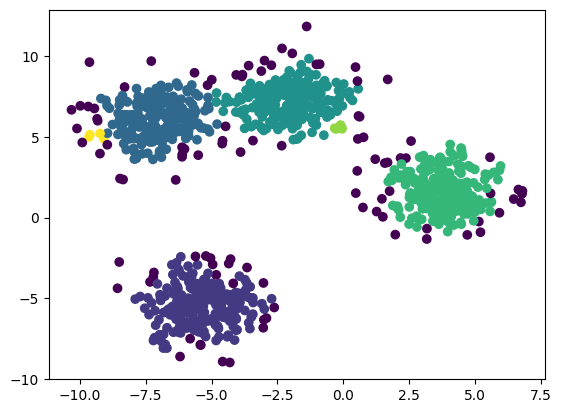

In [141]:
plt.scatter(df['Variable1'], df['Variable2'], c=labels, cmap='viridis')